# DP-SGD Epsilon Sweep on PTB-XL ECG Dataset

**Bachelor Thesis — Differential Privacy for Medical Data**

This notebook trains a ResNet-18 on the PTB-XL 12-lead ECG dataset using Opacus (DP-SGD) across multiple epsilon values, logs all results, and uses the **Kneedle algorithm** to find the optimal privacy-utility tradeoff epsilon.

### Setup on Kaggle
1. Go to [kaggle.com](https://www.kaggle.com) → New Notebook
2. Click **+ Add Data** → search `ptb-xl-a-large-publicly-available-electrocardiography-dataset` → Add
3. Set accelerator: **Settings → Accelerator → GPU P100**
4. Run all cells in order

### What this notebook does
- Loads PTB-XL (21,801 ECGs, 5 superclasses: NORM, MI, STTC, CD, HYP)
- Trains ResNet-18 at epsilon = `[0.5, 1.0, 2.0, 5.0, 10.0, 50.0, ∞ (no DP)]`
- Saves all results to `epsilon_sweep_results.csv`
- Finds optimal epsilon using the Kneedle knee-detection algorithm
- Plots the privacy-utility curve with optimal point marked

## Cell 1 — Install Dependencies

In [1]:
# Run once — installs Opacus, wfdb (PhysioNet reader), and kneed (Kneedle algorithm)
!pip install opacus==1.4.0 wfdb kneed --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.2 MB/s eta 0:00:00


## Cell 2 — Imports & Configuration

In [2]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer

import wfdb
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from opacus.utils.batch_memory_manager import BatchMemoryManager
from kneed import KneeLocator

warnings.filterwarnings('ignore')

# ─── PATHS ────────────────────────────────────────────────────────────────────
# Kaggle path (the dataset is pre-mounted at this location on Kaggle)
DATA_PATH = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
RESULTS_DIR = "/kaggle/working/dp_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# If running on Google Colab, change DATA_PATH to where you uploaded the dataset:
# DATA_PATH = "/content/ptbxl"

# ─── EXPERIMENT SETTINGS ─────────────────────────────────────────────────────
EPSILONS      = [0.5, 1.0, 2.0, 5.0, 10.0, 50.0, float('inf')]  # inf = no DP baseline
DELTA         = 1e-5      # Standard DP delta for a dataset of ~18k samples
MAX_GRAD_NORM = 1.0       # Gradient clipping norm for DP-SGD
EPOCHS        = 5         # Epochs per epsilon run (increase to 10-15 for better results)
BATCH_SIZE    = 64        # Physical batch size
MAX_PHY_BATCH = 64        # Max physical batch for BatchMemoryManager
LR            = 1e-3      # Learning rate
SEED          = 42
N_CLASSES     = 5         # NORM, MI, STTC, CD, HYP
SAMPLING_FREQ = 100       # Use 100 Hz records (1000 samples per record)

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Epsilons to sweep: {EPSILONS}")
print(f"Results will be saved to: {RESULTS_DIR}")

Device: cuda
Epsilons to sweep: [0.5, 1.0, 2.0, 5.0, 10.0, 50.0, inf]
Results will be saved to: /kaggle/working/dp_results


## Cell 3 — Load PTB-XL Metadata & Build 5-Class Labels

In [3]:
import ast

# ─── Load the metadata CSV ───────────────────────────────────────────────────
ptbxl_db  = pd.read_csv(os.path.join(DATA_PATH, 'ptbxl_database.csv'), index_col='ecg_id')
scp_codes = pd.read_csv(os.path.join(DATA_PATH, 'scp_statements.csv'), index_col=0)

# Parse the SCP code dicts stored as strings in the CSV
ptbxl_db['scp_codes'] = ptbxl_db['scp_codes'].apply(ast.literal_eval)

# ─── Map SCP codes → superclass ──────────────────────────────────────────────
# Only keep codes that have a defined superclass (NORM, MI, STTC, CD, HYP)
scp_codes = scp_codes[scp_codes['diagnostic'] == 1.0]

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def get_superclass_labels(scp_dict):
    """Return a binary vector [NORM, MI, STTC, CD, HYP] for one record."""
    labels = np.zeros(N_CLASSES, dtype=np.float32)
    for code, likelihood in scp_dict.items():
        if likelihood >= 100 and code in scp_codes.index:
            superclass = scp_codes.loc[code, 'diagnostic_class']
            if superclass in SUPERCLASSES:
                labels[SUPERCLASSES.index(superclass)] = 1.0
    return labels

ptbxl_db['label_vec'] = ptbxl_db['scp_codes'].apply(get_superclass_labels)

# Drop records with no valid superclass label
ptbxl_db = ptbxl_db[ptbxl_db['label_vec'].apply(lambda x: x.sum() > 0)].copy()

# ─── Use the predefined train/val/test splits (strat_fold 9 = val, 10 = test) ─
train_df = ptbxl_db[ptbxl_db['strat_fold'] <= 8].copy()
val_df   = ptbxl_db[ptbxl_db['strat_fold'] == 9].copy()
test_df  = ptbxl_db[ptbxl_db['strat_fold'] == 10].copy()

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Label columns: {SUPERCLASSES}")
print("Train class distribution:")
print(pd.DataFrame(np.vstack(train_df['label_vec'].values), columns=SUPERCLASSES).sum().astype(int))

Train: 13826 | Val: 1717 | Test: 1716
Label columns: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
Train class distribution:
NORM    5753
MI      2430
STTC    3661
CD      3815
HYP     1205
dtype: int64


## Cell 4 — ECGDataset Class

In [4]:
class ECGDataset(Dataset):
    """
    Loads PTB-XL ECG records using the wfdb library.
    Returns tensors of shape (1, 12, 1000) — 12 leads × 1000 samples (10 s at 100 Hz).
    Labels are 5-dimensional binary vectors for multi-label classification.
    """
    def __init__(self, df, data_root, sampling_freq=100):
        self.df = df.reset_index(drop=True)
        self.data_root = data_root
        self.freq_col  = 'filename_lr' if sampling_freq == 100 else 'filename_hr'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        fpath = os.path.join(self.data_root, row[self.freq_col])

        # wfdb reads the .hea/.dat record pair
        record = wfdb.rdrecord(fpath)
        signal = record.p_signal          # shape: (1000, 12)
        signal = signal.T                 # → (12, 1000)

        # Replace NaNs with 0 (rare missing leads)
        signal = np.nan_to_num(signal, nan=0.0)

        # Z-score normalise per lead
        mean = signal.mean(axis=1, keepdims=True)
        std  = signal.std(axis=1, keepdims=True) + 1e-8
        signal = (signal - mean) / std

        # Add channel dimension → (1, 12, 1000)
        signal = signal[np.newaxis, :, :].astype(np.float32)

        label = row['label_vec'].astype(np.float32)

        return torch.from_numpy(signal), torch.from_numpy(label)


def make_loaders(train_df, val_df, test_df, data_root, batch_size=64):
    """Create DataLoader objects for train, val, and test splits."""
    train_ds = ECGDataset(train_df, data_root)
    val_ds   = ECGDataset(val_df,   data_root)
    test_ds  = ECGDataset(test_df,  data_root)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


# Quick sanity check
train_loader, val_loader, test_loader = make_loaders(
    train_df, val_df, test_df, DATA_PATH, BATCH_SIZE
)
x_sample, y_sample = next(iter(train_loader))
print(f"Signal shape : {x_sample.shape}   — expected (N, 1, 12, 1000)")
print(f"Label shape  : {y_sample.shape}   — expected (N, 5)")
print(f"Train batches: {len(train_loader)}")

Signal shape : torch.Size([64, 1, 12, 1000])   — expected (N, 1, 12, 1000)
Label shape  : torch.Size([64, 5])   — expected (N, 5)
Train batches: 216


## Cell 5 — ResNet-18 Model for 12-Lead ECG

In [5]:
def replace_batchnorm(module):
    """Manually replace BatchNorm2d with GroupNorm — avoids PyTorch 2.6 pickle issue."""
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            num_channels = child.num_features
            num_groups = 32
            while num_channels % num_groups != 0:
                num_groups //= 2
            setattr(module, name, nn.GroupNorm(num_groups, num_channels))
        else:
            replace_batchnorm(child)
    return module

def build_model(n_classes=N_CLASSES):
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=(7,7), stride=(2,2), padding=(3,3), bias=False)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    model = replace_batchnorm(model)
    print("Model built — BatchNorm replaced with GroupNorm for Opacus")
    return model

# Test build
test_model = build_model()
test_model.eval()
with torch.no_grad():
    dummy = torch.zeros(2, 1, 12, 1000)
    out = test_model(dummy)
print(f"Output shape: {out.shape}  — expected (2, 5)")
del test_model

Model built — BatchNorm replaced with GroupNorm for Opacus
Output shape: torch.Size([2, 5])  — expected (2, 5)


## Cell 6 — Evaluation Helper

In [6]:
def evaluate(model, loader, criterion, device):
    """
    Runs inference on a DataLoader and returns:
      - val_loss  : average BCE loss
      - auroc_macro : macro-averaged AUROC across all 5 classes
      - auroc_micro : micro-averaged AUROC (flattens all labels)
    """
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            all_logits.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.cpu().numpy())

    preds  = np.vstack(all_logits)
    labels = np.vstack(all_labels)
    avg_loss = total_loss / len(loader.dataset)

    # Macro AUROC: average over classes
    auroc_macro = roc_auc_score(labels, preds, average='macro')
    # Micro AUROC: treats each label-sample pair independently
    auroc_micro = roc_auc_score(labels, preds, average='micro')

    return avg_loss, auroc_macro, auroc_micro

## Cell 7 — Core Training Function

In [7]:
def train_one_epsilon(epsilon, train_df, val_df, test_df, data_root,
                      epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE,
                      max_phy_batch=MAX_PHY_BATCH, max_grad_norm=MAX_GRAD_NORM,
                      delta=DELTA, device=DEVICE, results_dir=RESULTS_DIR,
                      n_classes=N_CLASSES):
    """
    Trains ResNet-18 on PTB-XL with DP-SGD at the given epsilon.
    If epsilon == inf, trains without any DP (baseline).

    Returns a dict with all metrics and saves a pickle checkpoint.
    """
    eps_label = 'inf' if epsilon == float('inf') else str(epsilon)
    print(f"\n{'='*60}")
    print(f" Training epsilon = {eps_label}")
    print(f"{'='*60}")

    # Fresh data loaders for each run (needed because DP alters the loader)
    train_loader, val_loader, test_loader = make_loaders(
        train_df, val_df, test_df, data_root, batch_size
    )

    # Fresh model
    model     = build_model(n_classes).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ─── Opacus DP-SGD setup ─────────────────────────────────────────────────
    if epsilon < float('inf'):
        privacy_engine = PrivacyEngine(accountant='rdp')
        # make_private_with_epsilon automatically sets the noise multiplier
        # so that (epsilon, delta)-DP is satisfied after `epochs` epochs
        model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
            module=model,
            optimizer=optimizer,
            data_loader=train_loader,
            target_epsilon=epsilon,
            target_delta=delta,
            epochs=epochs,
            max_grad_norm=max_grad_norm,
        )
        noise_mult = optimizer.noise_multiplier
        print(f"Noise multiplier set to: {noise_mult:.4f}")
    else:
        privacy_engine = None
        noise_mult = 0.0
        print("No DP — running baseline")

    # ─── Training loop ───────────────────────────────────────────────────────
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0

        if epsilon < float('inf'):
            # BatchMemoryManager handles the virtual-batch expansion inside DP-SGD
            with BatchMemoryManager(
                data_loader=train_loader,
                max_physical_batch_size=max_phy_batch,
                optimizer=optimizer
            ) as memory_safe_loader:
                for x, y in memory_safe_loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()
                    loss = criterion(model(x), y)
                    loss.backward()
                    optimizer.step()
                    train_loss += loss.item() * x.size(0)
            # Report the actual achieved epsilon
            achieved_eps = privacy_engine.get_epsilon(delta)
        else:
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(x), y)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * x.size(0)
            achieved_eps = float('inf')

        train_loss /= len(train_loader.dataset)
        val_loss, val_macro, val_micro = evaluate(model, val_loader, criterion, device)

        print(f"  Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val AUROC macro: {val_macro:.4f} | micro: {val_micro:.4f} | "
              f"ε achieved: {achieved_eps:.3f}")

        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_auroc_macro': val_macro,
            'val_auroc_micro': val_micro,
            'achieved_epsilon': achieved_eps,
        })

    # ─── Final test evaluation ────────────────────────────────────────────────
    test_loss, test_macro, test_micro = evaluate(model, test_loader, criterion, device)
    print(f"\n  TEST → Loss: {test_loss:.4f} | AUROC macro: {test_macro:.4f} | micro: {test_micro:.4f}")

    result = {
        'target_epsilon':  epsilon,
        'achieved_epsilon': history[-1]['achieved_epsilon'],
        'delta':           delta,
        'noise_multiplier': noise_mult,
        'test_loss':       test_loss,
        'test_auroc_macro': test_macro,
        'test_auroc_micro': test_micro,
        'history':         history,
    }

    # Save pickle checkpoint
    pkl_path = os.path.join(results_dir, f"result_eps{eps_label}.pkl")
    with open(pkl_path, 'wb') as f:
        pickle.dump(result, f)
    print(f"  Saved: {pkl_path}")

    return result

## Cell 8 — Run the Full Epsilon Sweep

> **⏱ Expected time on Kaggle P100:** ~10–15 min per epsilon × 7 epsilons ≈ 70–105 min total for 5 epochs.  
> To do a quick test first, set `EPOCHS = 2` in Cell 2 and run only one epsilon.

In [8]:
all_results = []

for eps in EPSILONS:
    result = train_one_epsilon(
        epsilon=eps,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        data_root=DATA_PATH,
    )
    all_results.append(result)

print("\n✅ All epsilon runs complete.")


 Training epsilon = 0.5
Model built — BatchNorm replaced with GroupNorm for Opacus


04/06/2026 23:56:45:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


Noise multiplier set to: 1.5039
  Epoch 1/5 | Train Loss: 0.5981 | Val Loss: 0.5775 | Val AUROC macro: 0.7102 | micro: 0.7305 | ε achieved: 0.364
  Epoch 2/5 | Train Loss: 0.5343 | Val Loss: 0.5065 | Val AUROC macro: 0.7579 | micro: 0.7460 | ε achieved: 0.400
  Epoch 3/5 | Train Loss: 0.4838 | Val Loss: 0.4751 | Val AUROC macro: 0.7727 | micro: 0.7765 | ε achieved: 0.432
  Epoch 4/5 | Train Loss: 0.4695 | Val Loss: 0.4587 | Val AUROC macro: 0.7818 | micro: 0.8143 | ε achieved: 0.464
  Epoch 5/5 | Train Loss: 0.4697 | Val Loss: 0.4302 | Val AUROC macro: 0.7907 | micro: 0.8350 | ε achieved: 0.495

  TEST → Loss: 0.4310 | AUROC macro: 0.7893 | micro: 0.8329
  Saved: /kaggle/working/dp_results/result_eps0.5.pkl

 Training epsilon = 1.0
Model built — BatchNorm replaced with GroupNorm for Opacus


04/07/2026 00:02:36:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


Noise multiplier set to: 1.0791
  Epoch 1/5 | Train Loss: 0.5829 | Val Loss: 0.5307 | Val AUROC macro: 0.7229 | micro: 0.7268 | ε achieved: 0.786
  Epoch 2/5 | Train Loss: 0.5129 | Val Loss: 0.4768 | Val AUROC macro: 0.7728 | micro: 0.7822 | ε achieved: 0.838
  Epoch 3/5 | Train Loss: 0.4631 | Val Loss: 0.4458 | Val AUROC macro: 0.7945 | micro: 0.8314 | ε achieved: 0.890
  Epoch 4/5 | Train Loss: 0.4567 | Val Loss: 0.4926 | Val AUROC macro: 0.8005 | micro: 0.8292 | ε achieved: 0.942
  Epoch 5/5 | Train Loss: 0.4521 | Val Loss: 0.4669 | Val AUROC macro: 0.8027 | micro: 0.8395 | ε achieved: 0.994

  TEST → Loss: 0.4704 | AUROC macro: 0.8046 | micro: 0.8372
  Saved: /kaggle/working/dp_results/result_eps1.0.pkl

 Training epsilon = 2.0
Model built — BatchNorm replaced with GroupNorm for Opacus


...

Noise multiplier set to: 0.6036
  Epoch 1/5 | Train Loss: 0.5565 | Val Loss: 0.4631 | Val AUROC macro: 0.7931 | micro: 0.7887 | ε achieved: 3.740
  Epoch 2/5 | Train Loss: 0.4688 | Val Loss: 0.3949 | Val AUROC macro: 0.8076 | micro: 0.8532 | ε achieved: 4.150
  Epoch 3/5 | Train Loss: 0.4247 | Val Loss: 0.4173 | Val AUROC macro: 0.8269 | micro: 0.8638 | ε achieved: 4.470
  Epoch 4/5 | Train Loss: 0.4177 | Val Loss: 0.4326 | Val AUROC macro: 0.8382 | micro: 0.8674 | ε achieved: 4.749
  Epoch 5/5 | Train Loss: 0.4095 | Val Loss: 0.3974 | Val AUROC macro: 0.8464 | micro: 0.8809 | ε achieved: 4.994

  TEST → Loss: 0.4056 | AUROC macro: 0.8458 | micro: 0.8777
  Saved: /kaggle/working/dp_results/result_eps5.0.pkl

 Training epsilon = 10.0
Model built — BatchNorm replaced with GroupNorm for Opacus


04/07/2026 00:16:26:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


Noise multiplier set to: 0.4884
  Epoch 1/5 | Train Loss: 0.5511 | Val Loss: 0.4354 | Val AUROC macro: 0.7953 | micro: 0.8014 | ε achieved: 6.942
  Epoch 2/5 | Train Loss: 0.4572 | Val Loss: 0.4242 | Val AUROC macro: 0.8056 | micro: 0.8500 | ε achieved: 7.964
  Epoch 3/5 | Train Loss: 0.4469 | Val Loss: 0.3922 | Val AUROC macro: 0.8284 | micro: 0.8615 | ε achieved: 8.735
  Epoch 4/5 | Train Loss: 0.4290 | Val Loss: 0.3981 | Val AUROC macro: 0.8419 | micro: 0.8743 | ε achieved: 9.408
  Epoch 5/5 | Train Loss: 0.4211 | Val Loss: 0.3729 | Val AUROC macro: 0.8488 | micro: 0.8772 | ε achieved: 9.995

  TEST → Loss: 0.3870 | AUROC macro: 0.8474 | micro: 0.8696
  Saved: /kaggle/working/dp_results/result_eps10.0.pkl

 Training epsilon = 50.0
Model built — BatchNorm replaced with GroupNorm for Opacus


04/07/2026 00:21:02:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


Noise multiplier set to: 0.2994
  Epoch 1/5 | Train Loss: 0.5355 | Val Loss: 0.4002 | Val AUROC macro: 0.8100 | micro: 0.8494 | ε achieved: 28.529
  Epoch 2/5 | Train Loss: 0.4426 | Val Loss: 0.3811 | Val AUROC macro: 0.8530 | micro: 0.8874 | ε achieved: 35.941
  Epoch 3/5 | Train Loss: 0.4206 | Val Loss: 0.4692 | Val AUROC macro: 0.8564 | micro: 0.8766 | ε achieved: 40.674
  Epoch 4/5 | Train Loss: 0.4056 | Val Loss: 0.3986 | Val AUROC macro: 0.8628 | micro: 0.8948 | ε achieved: 45.336
  Epoch 5/5 | Train Loss: 0.4126 | Val Loss: 0.3711 | Val AUROC macro: 0.8673 | micro: 0.8997 | ε achieved: 49.998

  TEST → Loss: 0.3764 | AUROC macro: 0.8662 | micro: 0.8967
  Saved: /kaggle/working/dp_results/result_eps50.0.pkl

 Training epsilon = inf
Model built — BatchNorm replaced with GroupNorm for Opacus
No DP — running baseline
  Epoch 1/5 | Train Loss: 0.4571 | Val Loss: 0.3298 | Val AUROC macro: 0.8723 | micro: 0.9008 | ε achieved: inf
  Epoch 2/5 | Train Loss: 0.3306 | Val Loss: 0.3009 | Va

## Cell 9 — Save All Results to CSV

In [9]:
# Build summary dataframe
rows = []
for r in all_results:
    rows.append({
        'target_epsilon':     r['target_epsilon'],
        'achieved_epsilon':   r['achieved_epsilon'],
        'delta':              r['delta'],
        'noise_multiplier':   r['noise_multiplier'],
        'test_loss':          r['test_loss'],
        'test_auroc_macro':   r['test_auroc_macro'],
        'test_auroc_micro':   r['test_auroc_micro'],
    })

results_df = pd.DataFrame(rows)

csv_path = '/kaggle/working/epsilon_sweep_results.csv'
results_df.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")
print()
print(results_df.to_string(index=False))

Results saved to: /kaggle/working/epsilon_sweep_results.csv

 target_epsilon  achieved_epsilon   delta  noise_multiplier  test_loss  test_auroc_macro  test_auroc_micro
            0.5          0.495359 0.00001          1.503906   0.430983          0.789251          0.832944
            1.0          0.993676 0.00001          1.079102   0.470365          0.804579          0.837201
            2.0          1.998900 0.00001          0.815430   0.405848          0.823587          0.857611
            5.0          4.993906 0.00001          0.603638   0.405586          0.845836          0.877669
           10.0          9.995061 0.00001          0.488358   0.387024          0.847431          0.869556
           50.0         49.997630 0.00001          0.299377   0.376372          0.866235          0.896680
            inf               inf 0.00001          0.000000   0.273349          0.907805          0.931470


## Cell 10 — Kneedle: Find the Optimal Epsilon

The **Kneedle algorithm** detects the "knee" (elbow) of a curve — the point of maximum curvature.  
On the privacy-utility tradeoff curve (x = epsilon, y = AUROC), this knee is the sweet spot where you gain the most privacy with the least loss in performance.

In [10]:
# Separate finite epsilons from the no-DP baseline
finite_results = [r for r in all_results if r['target_epsilon'] < float('inf')]
inf_result     = next((r for r in all_results if r['target_epsilon'] == float('inf')), None)

epsilons_finite = [r['target_epsilon']   for r in finite_results]
aurocs_micro    = [r['test_auroc_micro'] for r in finite_results]
aurocs_macro    = [r['test_auroc_macro'] for r in finite_results]

# ─── Kneedle on micro-AUROC ───────────────────────────────────────────────────
# curve='concave' + direction='increasing' matches a curve that rises quickly
# then flattens — typical for privacy-utility tradeoff
kneedle = KneeLocator(
    epsilons_finite,
    aurocs_micro,
    curve='concave',
    direction='increasing',
    interp_method='polynomial'
)

optimal_epsilon = kneedle.knee
if optimal_epsilon is None:
    # Fallback if Kneedle finds no clear knee (can happen with noisy or monotonic curves)
    optimal_epsilon = epsilons_finite[np.argmax(np.gradient(aurocs_micro))]
    print("Kneedle found no clear knee — using gradient-based fallback")

# Find the AUROC at the optimal epsilon
optimal_auroc = aurocs_micro[epsilons_finite.index(optimal_epsilon)] \
    if optimal_epsilon in epsilons_finite else None
baseline_auroc = inf_result['test_auroc_micro'] if inf_result else None

print(f"\n{'='*50}")
print(f" OPTIMAL EPSILON (Kneedle): ε = {optimal_epsilon}")
if optimal_auroc:
    print(f" AUROC at optimal ε:        {optimal_auroc:.4f}")
if baseline_auroc:
    print(f" Baseline (no DP) AUROC:    {baseline_auroc:.4f}")
    if optimal_auroc:
        gap = baseline_auroc - optimal_auroc
        print(f" Privacy cost (AUROC drop): {gap:.4f}  ({gap/baseline_auroc*100:.1f}% relative)")
print(f"{'='*50}")


 OPTIMAL EPSILON (Kneedle): ε = 5.0
 AUROC at optimal ε:        0.8777
 Baseline (no DP) AUROC:    0.9315
 Privacy cost (AUROC drop): 0.0538  (5.8% relative)


## Cell 11 — Plot: Privacy-Utility Curve + Bar Chart

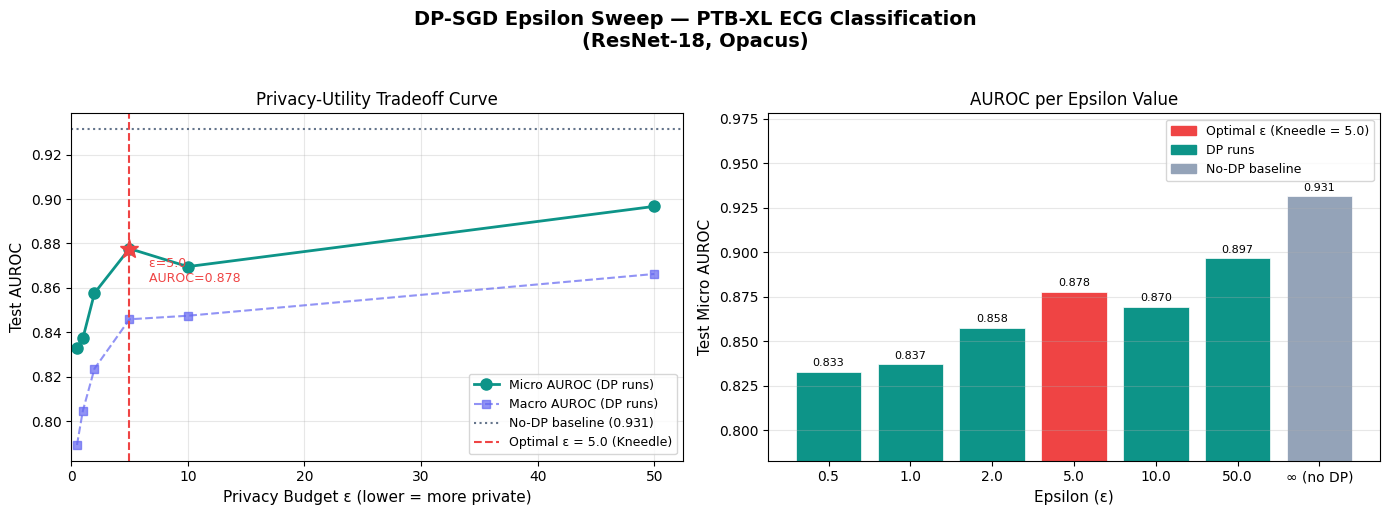

Plot saved to: /kaggle/working/privacy_utility_curve.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DP-SGD Epsilon Sweep — PTB-XL ECG Classification\n(ResNet-18, Opacus)',
             fontsize=14, fontweight='bold', y=1.02)

# ─── Panel 1: Privacy-Utility Curve ─────────────────────────────────────────
ax = axes[0]
ax.plot(epsilons_finite, aurocs_micro, 'o-', color='#0D9488', linewidth=2,
        markersize=8, label='Micro AUROC (DP runs)')
ax.plot(epsilons_finite, aurocs_macro, 's--', color='#6366F1', linewidth=1.5,
        markersize=6, alpha=0.7, label='Macro AUROC (DP runs)')

# Baseline (no DP) as horizontal dashed line
if baseline_auroc:
    ax.axhline(y=baseline_auroc, color='#64748B', linestyle=':', linewidth=1.5,
               label=f'No-DP baseline ({baseline_auroc:.3f})')

# Mark the optimal epsilon (knee point)
if optimal_epsilon is not None and optimal_auroc is not None:
    ax.axvline(x=optimal_epsilon, color='#EF4444', linestyle='--', linewidth=1.5,
               label=f'Optimal ε = {optimal_epsilon} (Kneedle)')
    ax.plot(optimal_epsilon, optimal_auroc, '*', color='#EF4444', markersize=14,
            zorder=5)
    ax.annotate(f'  ε={optimal_epsilon}\n  AUROC={optimal_auroc:.3f}',
                xy=(optimal_epsilon, optimal_auroc),
                fontsize=9, color='#EF4444',
                xytext=(optimal_epsilon + 1, optimal_auroc - 0.015))

ax.set_xlabel('Privacy Budget ε (lower = more private)', fontsize=11)
ax.set_ylabel('Test AUROC', fontsize=11)
ax.set_title('Privacy-Utility Tradeoff Curve', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)

# ─── Panel 2: Bar Chart per Epsilon ─────────────────────────────────────────
ax2 = axes[1]
all_eps_labels = [str(e) for e in epsilons_finite] + (['∞ (no DP)'] if baseline_auroc else [])
all_aurocs     = aurocs_micro + ([baseline_auroc] if baseline_auroc else [])

bar_colors = []
for e in epsilons_finite:
    bar_colors.append('#EF4444' if e == optimal_epsilon else '#0D9488')
if baseline_auroc:
    bar_colors.append('#94A3B8')

bars = ax2.bar(all_eps_labels, all_aurocs, color=bar_colors, edgecolor='white',
               linewidth=0.5)

# Add value labels on top of bars
for bar, val in zip(bars, all_aurocs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax2.set_xlabel('Epsilon (ε)', fontsize=11)
ax2.set_ylabel('Test Micro AUROC', fontsize=11)
ax2.set_title('AUROC per Epsilon Value', fontsize=12)
ax2.set_ylim(bottom=max(0, min(all_aurocs) - 0.05))
ax2.grid(True, axis='y', alpha=0.3)

# Legend patches
legend_patches = [
    mpatches.Patch(color='#EF4444', label=f'Optimal ε (Kneedle = {optimal_epsilon})'),
    mpatches.Patch(color='#0D9488', label='DP runs'),
    mpatches.Patch(color='#94A3B8', label='No-DP baseline'),
]
ax2.legend(handles=legend_patches, fontsize=9)

plt.tight_layout()
plot_path = '/kaggle/working/privacy_utility_curve.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {plot_path}")

## Cell 12 — Final Summary Table

In [12]:
print("\n" + "="*70)
print(" FINAL RESULTS SUMMARY")
print("="*70)
print(results_df[['target_epsilon', 'achieved_epsilon', 'test_auroc_micro',
                   'test_auroc_macro', 'noise_multiplier']].to_string(index=False))

print(f"\n{'─'*70}")
print(f"  Optimal Epsilon (Kneedle) : ε = {optimal_epsilon}")
if optimal_auroc:
    print(f"  AUROC at optimal ε        : {optimal_auroc:.4f}")
if baseline_auroc:
    print(f"  No-DP baseline AUROC      : {baseline_auroc:.4f}")
print(f"{'─'*70}")
print()
print("Output files:")
print(f"  📊 CSV    → /kaggle/working/epsilon_sweep_results.csv")
print(f"  📈 Plot   → /kaggle/working/privacy_utility_curve.png")
print(f"  💾 Pickles → {RESULTS_DIR}/result_eps*.pkl")
print()
print("To download outputs: Kaggle → Output tab → Download All")


 FINAL RESULTS SUMMARY
 target_epsilon  achieved_epsilon  test_auroc_micro  test_auroc_macro  noise_multiplier
            0.5          0.495359          0.832944          0.789251          1.503906
            1.0          0.993676          0.837201          0.804579          1.079102
            2.0          1.998900          0.857611          0.823587          0.815430
            5.0          4.993906          0.877669          0.845836          0.603638
           10.0          9.995061          0.869556          0.847431          0.488358
           50.0         49.997630          0.896680          0.866235          0.299377
            inf               inf          0.931470          0.907805          0.000000

──────────────────────────────────────────────────────────────────────
  Optimal Epsilon (Kneedle) : ε = 5.0
  AUROC at optimal ε        : 0.8777
  No-DP baseline AUROC      : 0.9315
──────────────────────────────────────────────────────────────────────

Output files:
  

---
## Appendix — Interpreting Results

| Term | Meaning |
|---|---|
| **ε (epsilon)** | Privacy budget. Lower = stronger privacy, more noise. ε=1 is very strict; ε=50 is nearly no privacy. |
| **δ (delta)** | Probability of a small privacy leak. Set to 1/N (here 1e-5 for ~18k samples). |
| **AUROC (micro)** | Area Under ROC Curve across all label-sample pairs. Higher is better (max = 1.0). |
| **AUROC (macro)** | AUROC averaged per class. Treats all 5 classes equally regardless of frequency. |
| **Noise multiplier** | σ in DP-SGD. Higher σ = more privacy but more noise. Automatically set by Opacus. |
| **Kneedle knee** | The ε where the AUROC curve bends — maximum curvature point. Best privacy-utility tradeoff. |

### What to report in your thesis
1. Table of all epsilons with achieved ε, AUROC macro, AUROC micro, noise multiplier
2. Privacy-utility tradeoff curve with the Kneedle knee marked
3. Comparison: DP model at optimal ε vs. no-DP baseline
4. Discuss: what is the cost of privacy in % AUROC? Is ε=2 acceptable for clinical use?

### Typical expected results (based on literature)
- No-DP baseline: AUROC ~0.88–0.93
- ε=1: AUROC ~0.70–0.78 (high privacy cost)
- ε=2: AUROC ~0.78–0.84
- ε=10: AUROC ~0.85–0.91 (near-baseline)
- Optimal knee: typically ε=2–5 for ECG classification